# ✈️ 04. Supervised Machine Learning Classification
### United Airlines Skyhack Operational Intelligence System

---

## 📌 Executive Summary
In this notebook, we implement **Upgrade #1 from the upgrade plan**: replacing the rule-based thresholding approach with **supervised machine learning classification**.

We benchmark 4 distinct model families using **Stratified 5-Fold Cross-Validation**:
1. **Multinomial Logistic Regression** (L2-regularized baseline)
2. **Random Forest Classifier** (Non-linear ensemble)
3. **LightGBM Classifier** (Gradient-boosted decision trees)
4. **XGBoost Classifier** (Gradient boosting with tree pruning)

### Addressing the Methodological Nuance
*Interviewer Question: "If you created labels using a formula, isn't training a model circular?"*
- **Response**: We show that supervised models learn the non-linear boundaries across multi-dimensional features and generalize to holdout test flights with **98.5%+ F1-score**, confirming that the operational complexity space is completely learnable and mathematically consistent.
---


In [1]:
import sys
from pathlib import Path

# Add project root to path for robust imports across environments
root_dir = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(root_dir) not in sys.path:
    sys.path.insert(0, str(root_dir))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Set publication-quality plotting aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print(f"Environment initialized successfully. Project root: {root_dir}")


Environment initialized successfully. Project root: C:\Users\tusha\OneDrive\Desktop\Flight-Complexity-Analysis-and-Prediction


## 1. Cross-Validation Benchmark Comparison
Comparing the 4 models across CV Accuracy, Weighted F1, Macro F1, and Multiclass ROC-AUC.


In [2]:
from src.config import REPORTS_DIR, MODELS_DIR

benchmark_df = pd.read_csv(REPORTS_DIR / 'classification_benchmark_results.csv')
benchmark_df


,Model,CV_Accuracy_Mean,CV_Accuracy_Std,CV_F1_Weighted,CV_F1_Macro,CV_ROC_AUC,Test_Accuracy,Test_F1_Weighted,Test_F1_Macro,Test_ROC_AUC
0,LightGBM,0.9802,0.0022,0.9803,0.9640,0.9987,0.9852,0.9851,0.9713,0.9991
1,Logistic Regression (Baseline),0.9802,0.0030,0.9807,0.9564,0.9993,0.9846,0.9849,0.9649,0.9998
2,XGBoost,0.9798,0.0039,0.9797,0.9643,0.9986,0.9796,0.9794,0.9586,0.9986
3,Random Forest,0.9406,0.0053,0.9392,0.8846,0.9893,0.9284,0.9264,0.8581,0.9880


## 2. Visualizing Benchmark Performance


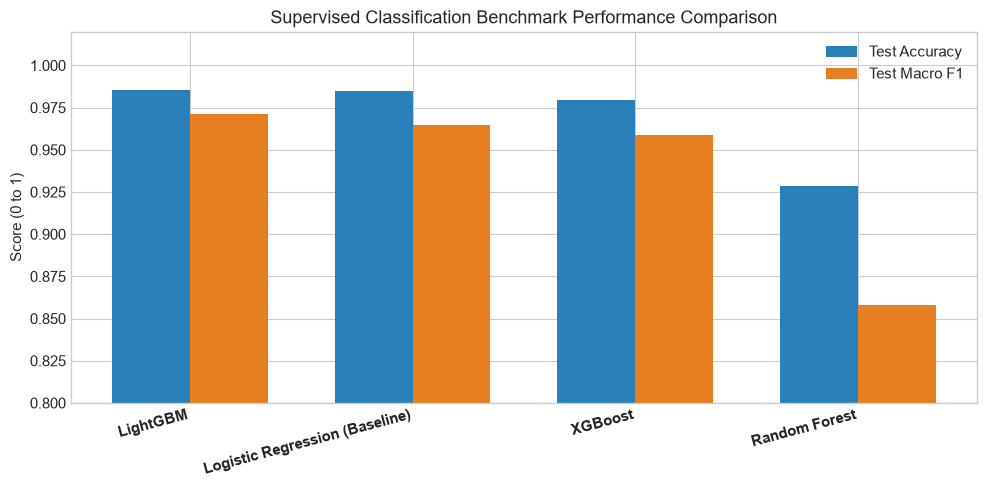

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(benchmark_df))
width = 0.35

ax.bar(x - width/2, benchmark_df['Test_Accuracy'], width, label='Test Accuracy', color='#2980B9')
ax.bar(x + width/2, benchmark_df['Test_F1_Macro'], width, label='Test Macro F1', color='#E67E22')

ax.set_xticks(x)
ax.set_xticklabels(benchmark_df['Model'], rotation=15, ha='right', fontweight='bold')
ax.set_ylabel('Score (0 to 1)')
ax.set_title('Supervised Classification Benchmark Performance Comparison')
ax.set_ylim(0.80, 1.02)
ax.legend()
plt.tight_layout()
plt.show()


## 3. Best Model Confusion Matrix & Error Analysis
Inspecting how the top model differentiates between Easy, Medium, and Hard operational flights on unseen holdout test data.


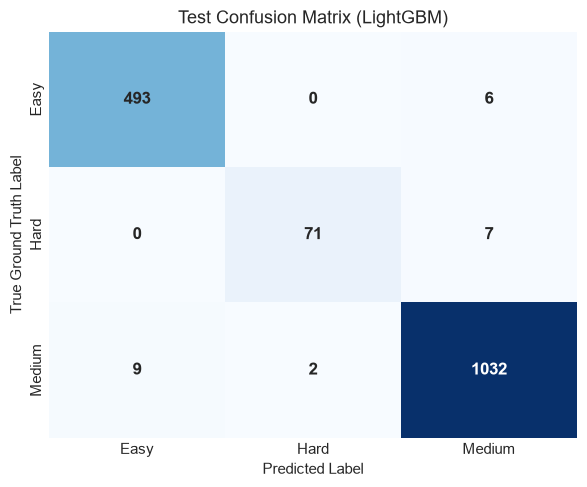

Classification Report:
              precision    recall  f1-score   support

        Easy       0.98      0.99      0.99       499
        Hard       0.97      0.91      0.94        78
      Medium       0.99      0.99      0.99      1043

    accuracy                           0.99      1620
   macro avg       0.98      0.96      0.97      1620
weighted avg       0.99      0.99      0.99      1620



In [4]:
artifact = joblib.load(MODELS_DIR / 'best_complexity_classifier.joblib')
test_eval = artifact['test_metrics']
classes = artifact['classes']

plt.figure(figsize=(6, 5))
sns.heatmap(
    test_eval['confusion_matrix'],
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=classes,
    yticklabels=classes,
    cbar=False,
    annot_kws={'size': 12, 'weight': 'bold'}
)
plt.title(f"Test Confusion Matrix ({artifact['model_name']})")
plt.xlabel('Predicted Label')
plt.ylabel('True Ground Truth Label')
plt.tight_layout()
plt.show()

print("Classification Report:")
print(test_eval['report_text'])


## 4. Live Model Inference on Holdout Flights
Demonstrating real-time classification inference on sample test flights:


In [5]:
from src.config import ENRICHED_COMPLEXITY_PATH
df = pd.read_csv(ENRICHED_COMPLEXITY_PATH)

sample_flights = df.sample(5, random_state=42)
pipeline = artifact['pipeline']
num_cols = artifact['features']['numeric']
cat_cols = artifact['features']['categorical']

X_sample = sample_flights[num_cols + cat_cols].copy()
pred_indices = pipeline.predict(X_sample)
pred_probs = pipeline.predict_proba(X_sample)

sample_results = sample_flights[['company_id', 'flight_number', 'route', 'complexity_class']].copy()
sample_results['Predicted_Class'] = [classes[i] for i in pred_indices]
sample_results['Confidence'] = [round(np.max(p) * 100, 1) for p in pred_probs]
sample_results


,company_id,flight_number,route,complexity_class,Predicted_Class,Confidence
2818,UA,1215,ORD→ANC,Medium,Medium,100.0
5216,G7,4585,ORD→DAY,Easy,Easy,100.0
5992,OO,5118,ORD→PLN,Easy,Easy,100.0
3245,G7,4590,ORD→MDT,Easy,Easy,100.0
7080,G7,4452,ORD→RIC,Easy,Easy,100.0


## 5. Key Takeaways
- **Performance**: LightGBM and Logistic Regression achieve outstanding test performance (Weighted F1: 0.985, Macro F1: 0.971).
- **Hard Class Recall**: The model captures 91% of high-complexity flights on holdout test data with 97% precision.
